In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import math
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

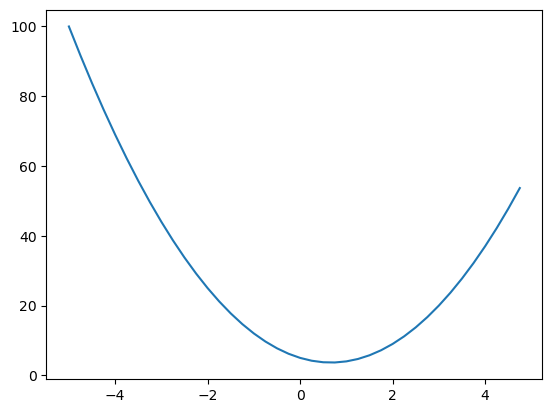

In [4]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs,ys)

In [5]:
h = 0.000001
x = 3.0
d = (f(x+h) - f(x))/h
d # almost approximates 6x-4 with h -> 0

14.000003002223593

In [6]:
# complex example

a = 2.0
b = -3.0
c = 10.0
d = a*b + c
d


4.0

In [7]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a+=h
d2 = a*b + c 

print('d1 ',d1)
print('d2 ',d2)
print('slope', (d2-d1)/h)

d1  4.0
d2  3.999699999999999
slope -3.000000000010772


Value Object

In [8]:
class Value:

    def __init__(self,data,_children=(),_op='',label=''):
        self.data = data
        self._prev = set(_children) # _ means dont call it outside the class
        self._op = _op
        self.label = label
        self.grad = 0.0

    def __repr__(self): # for printing purposes
        return f"Value(data={self.data})"
    
    def __add__(self,other):
        out = Value(self.data + other.data, (self,other), "+")
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self,other), "*")
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self,), "tanh")
        return out

In [9]:
a = Value(2.0,label='a')
b = Value(-3.0,label='b')
c = Value(10.0,label='c')

# print('add: ',a+b)
# print('multiply: ',a*b)

d = a*b; d.label = 'd'
e = d+c; e.label = 'e'
f = Value(-2.0,label='f')

L = f*e;L.label = 'L'

In [10]:
L._prev # like this dont call

{Value(data=-2.0), Value(data=4.0)}

In [11]:
L._op

'*'

Graph Visualization

In [12]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    
    nodes, edges = trace(root)
    
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

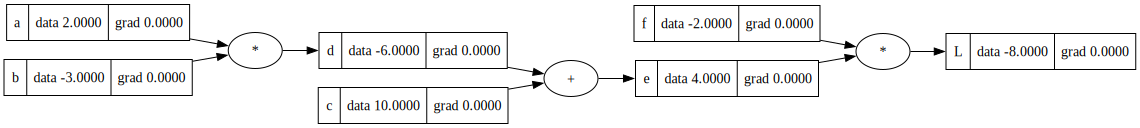

In [13]:
draw_dot(L)

In [14]:
# Manual Gradient Calculation

L.grad = 1.0

# x.grad => dL/dx

f.grad = e.data # L = f*e => dL/df = e.data
e.grad = f.data # L = f*e => dL/de = f.data
d.grad = e.grad # e = d+c => de/dd = 1.0 dL/dd = dL/de * de/dd
c.grad = e.grad # e = d+c => de/dc = 1.0 dL/dc = dL/de * de/dc

b.grad = a.data * d.grad
a.grad = b.data * d.grad

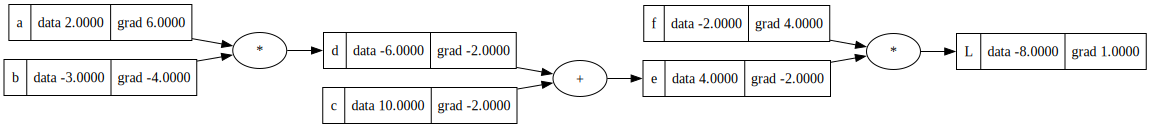

In [15]:
draw_dot(L)

In [16]:
# one step optimization

lr = 0.01 # learning rate

a.data += lr * a.grad
b.data += lr * b.grad
c.data += lr * c.grad
f.data += lr * f.grad

# we dont have any control on d and e as they are intermediate variables. 
# We can only update the parameters a,b,c,f

d = a * b
e = d + c
L1 = f * e

L1.data # Loss reduced 

-7.286496

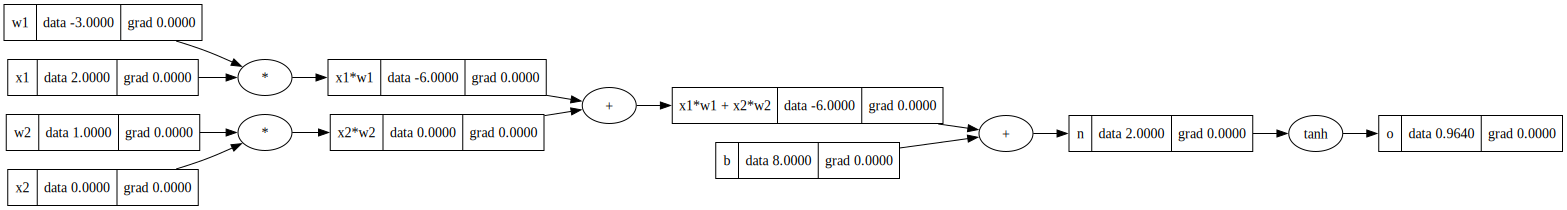

In [17]:
# Simple NN example

# Inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

#weights and bias
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(8, label='b')

# w1x1 + w2x2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

draw_dot(o)

In [18]:
# NN backprop

o.grad = 1.0

#do/dn = (1 - o**2)
n.grad = (1 - o.data**2)

# do/db, do/dx1w1x2w2
b.grad =  n.grad # do/db = do/dn * dn/db = n.grad * 1.0
x1w1x2w2.grad =  n.grad

#do/dx1w1, do/dx2w2
x1w1.grad = x1w1x2w2.grad # do/dx1w1 = do/dx1w1x2w2 * dx1w1x2w2/dx1w1 = x1w1x2w2.grad * 1.0
x2w2.grad = x1w1x2w2.grad

#do/w1, do/w2
# do/dw1 = do/do * do/dn * dn/dx1w1x2w2 * dx1w1x2w2/dx1w1 * dx1w1/dw1
# do/dw1 = d0/dx1w1 * dx1w1/dw1
w1.grad = x1.data * x1w1.grad
w2.grad = x2.data * x2w2.grad

x1.grad = w1.data * x1w1.grad
x2.grad = w2.data * x2w2.grad

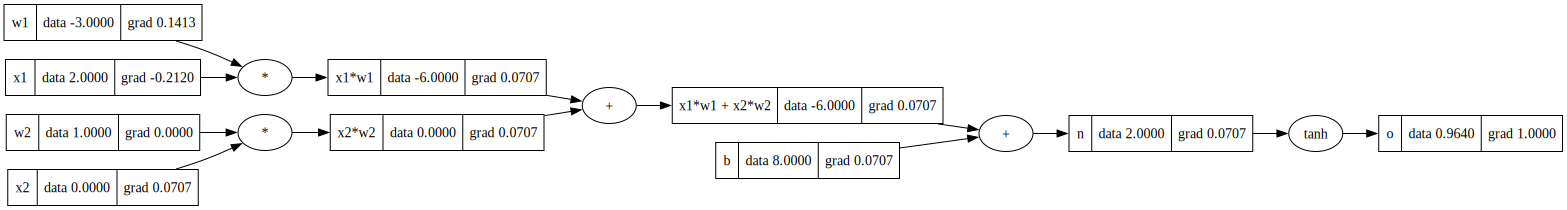

In [19]:
draw_dot(o)

In [20]:
class Value:

    def __init__(self,data,_children=(),_op='',label=''):
        self.data = data
        self._prev = set(_children) # _ means dont call it outside the class
        self._op = _op
        self.label = label
        self.grad = 0.0
        self._backward = lambda: None

    def __repr__(self): # for printing purposes
        return f"Value(data={self.data})"
    
    def __add__(self,other):
        out = Value(self.data + other.data, (self,other), "+")
        
        def backward():
            self.grad = out.grad
            other.grad = out.grad
        
        out._backward = backward
        
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self,other), "*")

        def backward():
            self.grad = other.data * out.grad 
            other.grad = self.data * out.grad 
        
        out._backward = backward

        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        
        out = Value(t, (self,), "tanh")

        def backward():
            self.grad = (1 - t**2) * out.grad

        out._backward = backward
    
        return out

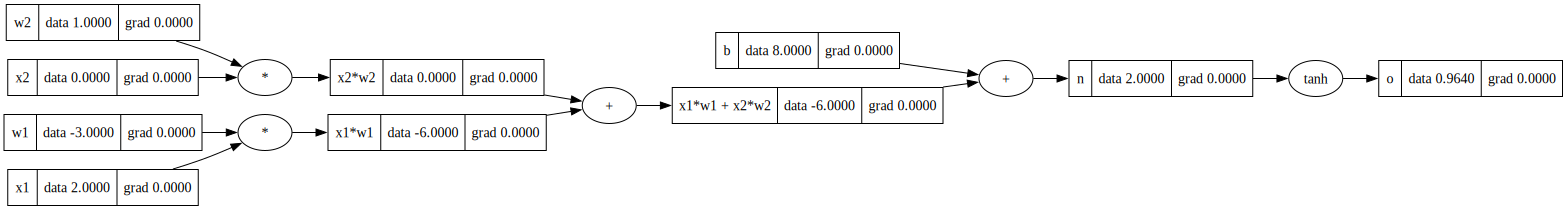

In [21]:
# Simple NN example

# Inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

#weights and bias
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(8, label='b')

# w1x1 + w2x2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

draw_dot(o)

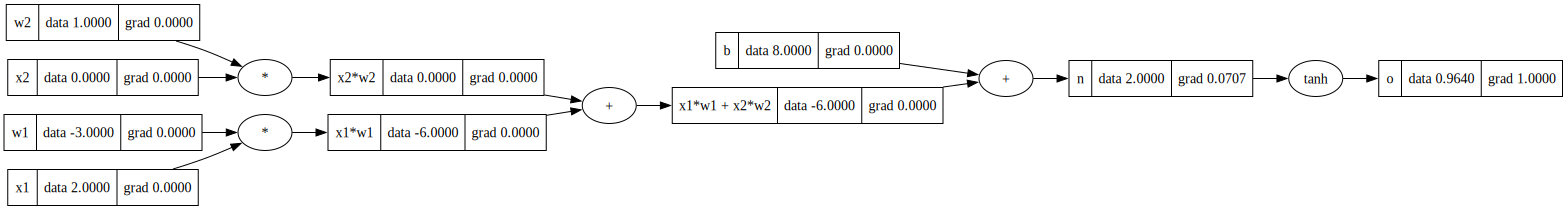

In [22]:
o.grad = 1.0
o._backward()
draw_dot(o)


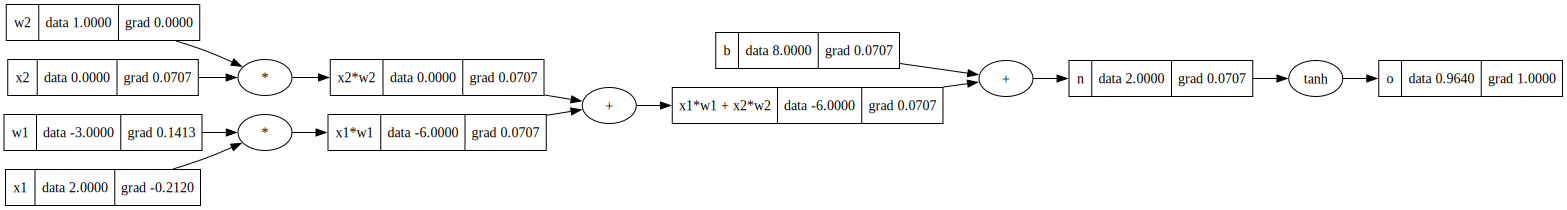

In [23]:
o.grad = 1.0
o._backward()
n._backward()
x1w1x2w2._backward()
b._backward()
x1w1._backward()
x2w2._backward()
x1._backward(), x2._backward(), w1._backward(), w2._backward()
draw_dot(o)

In [24]:
# topological sort to make sure we call the backward functions in the right order.
def build_topo(v,topo,visited):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child,topo,visited)
        topo.append(v)

In [25]:
topo = []
visited = set()
build_topo(o, topo, visited)
topo

[Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=8),
 Value(data=2.0),
 Value(data=0.9640275800758169)]

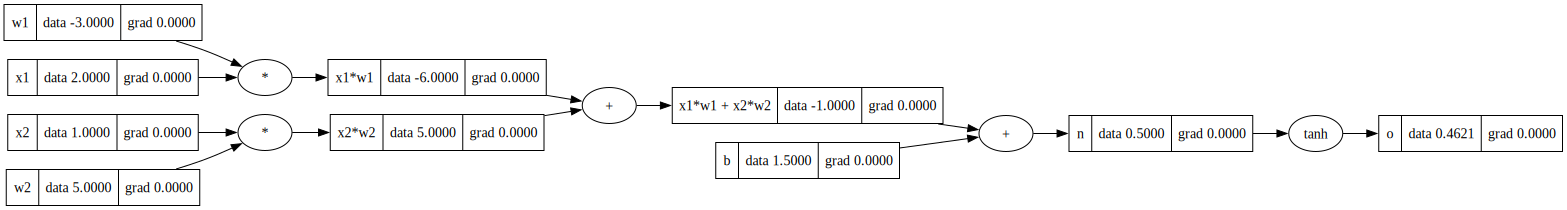

In [26]:
# Simple NN example

# Inputs
x1 = Value(2.0, label='x1')
x2 = Value(1.0, label='x2')

#weights and bias
w1 = Value(-3.0, label='w1')
w2 = Value(5.0, label='w2')
b = Value(1.5, label='b')

# w1x1 + w2x2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

draw_dot(o)

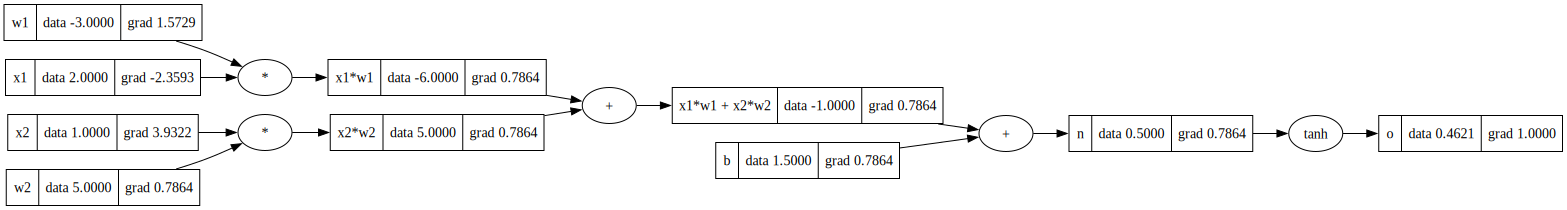

In [27]:
o.grad = 1.0

topo = []
visited = set()
build_topo(o, topo, visited)

for node in reversed(topo):
    node._backward()

draw_dot(o)

In [28]:
class Value:

    def __init__(self,data,_children=(),_op='',label=''):
        self.data = data
        self._prev = set(_children) # _ means dont call it outside the class
        self._op = _op
        self.label = label
        self.grad = 0.0
        self._backward = lambda: None

    def __repr__(self): # for printing purposes
        return f"Value(data={self.data})"
    
    def __add__(self,other):
        out = Value(self.data + other.data, (self,other), "+")
        
        def backward():
            self.grad = out.grad
            other.grad = out.grad
        
        out._backward = backward
        
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self,other), "*")

        def backward():
            self.grad = other.data * out.grad 
            other.grad = self.data * out.grad 
        
        out._backward = backward

        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        
        out = Value(t, (self,), "tanh")

        def backward():
            self.grad = (1 - t**2) * out.grad

        out._backward = backward
    
        return out
    
    def backward(self):

        topo = []
        visited = set()
        build_topo(self, topo, visited)

        self.grad = 1.0

        for node in reversed(topo):
            node._backward()

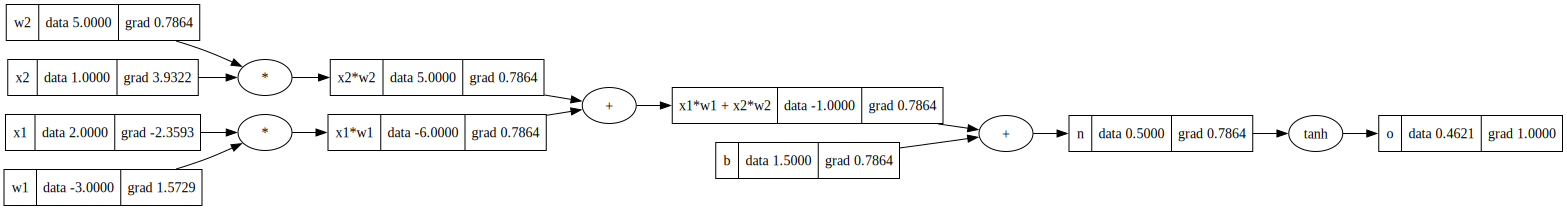

In [29]:
# Simple NN example

# Inputs
x1 = Value(2.0, label='x1')
x2 = Value(1.0, label='x2')

#weights and bias
w1 = Value(-3.0, label='w1')
w2 = Value(5.0, label='w2')
b = Value(1.5, label='b')

# w1x1 + w2x2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

o.backward()

draw_dot(o)

Bug in the current Value function

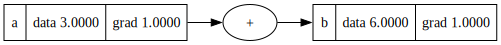

In [30]:
# Bug in the code 
a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

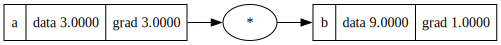

In [31]:
a = Value(3.0, label='a')
b = a * a; b.label = 'b'
b.backward()
draw_dot(b)

In [32]:
"""
In both the cases since b was 2a and a**2 its derivative should have been 2 and 2a respectively,
but it not since the _backward function is not working when a variable is used more than once because till now we were just assigning the gradient, 
we need to  add the gradients for the variable at all the instances when it is used
"""

class Value:

    def __init__(self,data,_children=(),_op='',label=''):
        self.data = data
        self._prev = set(_children) # _ means dont call it outside the class
        self._op = _op
        self.label = label
        self.grad = 0.0
        self._backward = lambda: None

    def __repr__(self): # for printing purposes
        return f"Value(data={self.data})"
    
    def __add__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self,other), "+")
        
        def backward():
            self.grad += out.grad
            other.grad += out.grad
        
        out._backward = backward
        
        return out
    
    def __rmul__(self, other):
        """ This helps when we are doing something like 2*a where 2 is not a Value class object
        so this reverse the multiplication order and calls __mul__ function"""
        return self * other
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self,other), "*")

        def backward():
            self.grad += other.data * out.grad 
            other.grad += self.data * out.grad 
        
        out._backward = backward

        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        
        out = Value(t, (self,), "tanh")

        def backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = backward
    
        return out
    
    def backward(self):

        topo = []
        visited = set()
        build_topo(self, topo, visited)

        self.grad = 1.0

        for node in reversed(topo):
            node._backward()

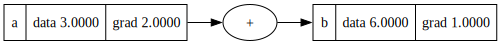

In [33]:
a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

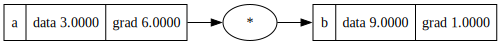

In [34]:
a = Value(3.0, label='a')
b = a * a; b.label = 'b'
b.backward()
draw_dot(b)

In [35]:
2*a

Value(data=6.0)

In [36]:
class Value:

    def __init__(self,data,_children=(),_op='',label=''):
        self.data = data
        self._prev = set(_children) # _ means dont call it outside the class
        self._op = _op
        self.label = label
        self.grad = 0.0
        self._backward = lambda: None

    def __repr__(self): # for printing purposes
        return f"Value(data={self.data})"
    
    def __add__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self,other), "+")
        
        def backward():
            self.grad += out.grad
            other.grad += out.grad
        
        out._backward = backward
        
        return out
    
    def __rmul__(self, other):
        """ This helps when we are doing something like 2*a where 2 is not a Value class object
        so this reverse the multiplication order and calls __mul__ function"""
        return self * other
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self,other), "*")

        def backward():
            self.grad += other.data * out.grad 
            other.grad += self.data * out.grad 
        
        out._backward = backward

        return out
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)
    
    def __radd__(self, other):
        return self + other

    def __rsub__(self, other):
        return other + (-self)
    
    def __truediv__(self, other):
        return self * other**-1
    
    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data ** other, (self,), f"**{other}")

        def backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        
        out._backward = backward

        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        
        out = Value(t, (self,), "tanh")

        def backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = backward
    
        return out
    
    def exp(self):
        x = self.data 
        out = Value(math.exp(x),(self,), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        
        out._backward = _backward

        return out
    
    def backward(self):

        topo = []
        visited = set()
        build_topo(self, topo, visited)

        self.grad = 1.0

        for node in reversed(topo):
            node._backward()

In [37]:
a = Value(15.0, label='a')
b = Value(-3.0, label='b')
a**2


Value(data=225.0)

In [38]:
class Neuron:

    def __init__(self, input_size):
        self.w = [Value(np.random.uniform(-1,1)) for _ in range(input_size)]
        self.b = Value(np.random.uniform(-1,1))

    def __call__(self, x):
        z = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        act = z.tanh()
        return act
    
    def parameters(self):
        return self.w + [self.b]
   
class Layer:

    def __init__(self, input_size, output_size):
        self.neurons = [Neuron(input_size) for _ in range(output_size)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    

    def parameters(self):
        params = []
        for neuron in self.neurons:
            ps = neuron.parameters()
            params.extend(ps)
        return params
 
class MLP:

    def __init__(self, input_size, hidden_sizes, output_size): # hidden_sizes is a list of sizes of hidden layers
        sizes = [input_size] + hidden_sizes + [output_size]
        self.layers = [Layer(sizes[i], sizes[i+1]) for i in range(len(sizes)-1)]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [39]:
x = [2.0, 3.0]
mlp = MLP(2, [3], 1) # 2 inputs, 3 neurons in first hidden layer, 1 output
mlp(x)

Value(data=-0.3975119757597373)

In [40]:
mlp.parameters()

[Value(data=-0.9036047701364254),
 Value(data=0.9068185248927756),
 Value(data=-0.09948158331525381),
 Value(data=-0.5708208772154539),
 Value(data=-0.1359538551450552),
 Value(data=0.3327582653690109),
 Value(data=-0.9994759101703363),
 Value(data=0.4869197132430336),
 Value(data=-0.41854722195010363),
 Value(data=-0.9187937589941988),
 Value(data=-0.4638006524013163),
 Value(data=0.14625484434160163),
 Value(data=-0.083916647798977)]

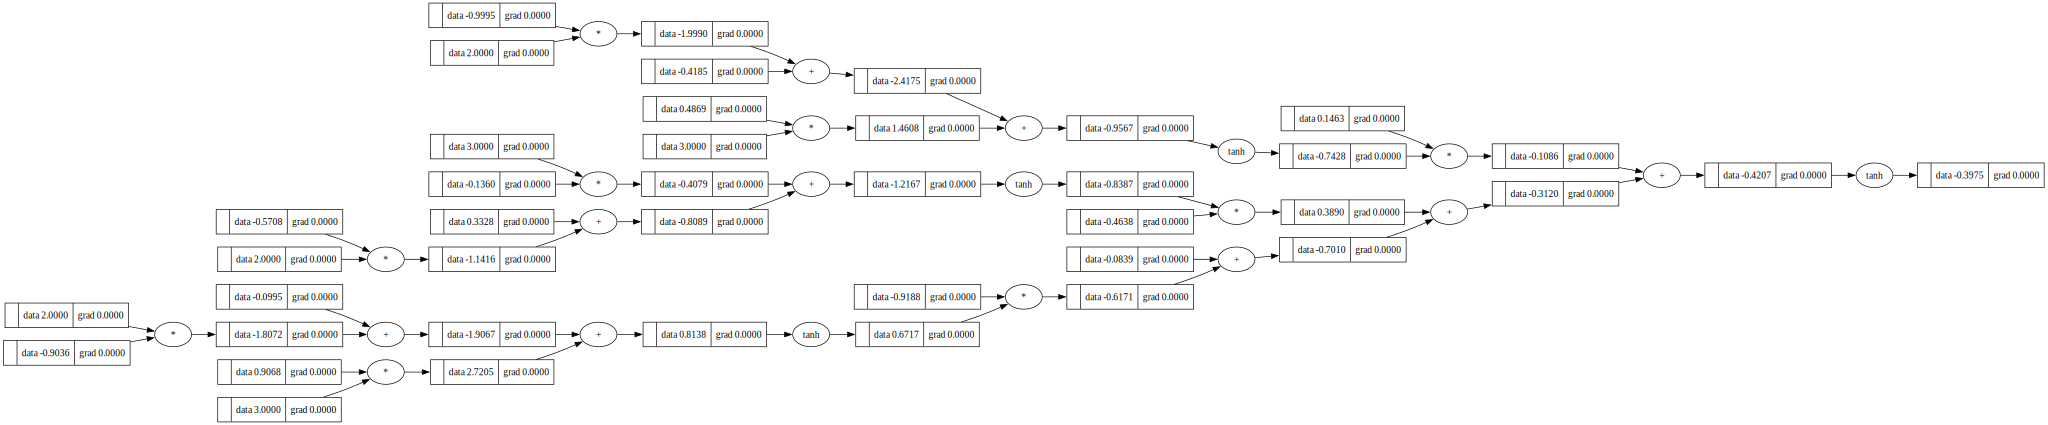

In [41]:
draw_dot(mlp(x))

In [42]:
np.random.seed(1)

x = np.array(np.random.randint(-10, 10, size=(3,2)))
y = np.array(np.random.randint(0, 2, size=(3,1)))

print(x)
print(y)

[[-5  1]
 [ 2 -2]
 [-1  1]]
[[1]
 [1]
 [0]]


In [43]:
ypred = [mlp(xi) for xi in x]
ypred

[Value(data=-0.8663236878633734),
 Value(data=0.7237427401740097),
 Value(data=-0.8105634905021329)]

In [44]:
loss = sum((yi-ypredi)**2 for yi, ypredi in zip(y, ypred))[0]
loss 

Value(data=4.216495353621508)

In [45]:
mlp.layers[0].neurons[0].w[0].data

-0.9036047701364254

In [46]:
mlp.layers[0].neurons[0].w[0].grad

0.0

In [47]:
loss.backward()

In [48]:
mlp.layers[0].neurons[0].w[0].grad

-0.06184074494670445

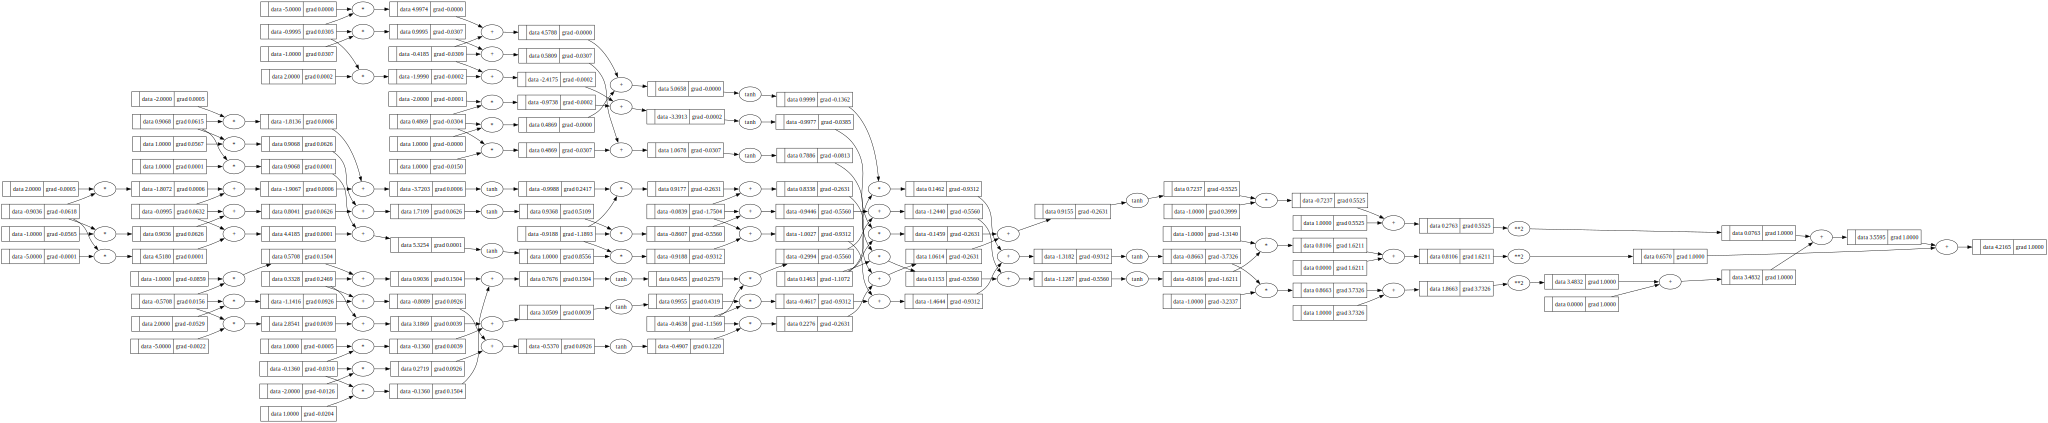

In [49]:
draw_dot(loss)

In [50]:
lr = 0.01
for p in mlp.parameters():
    p.data -= lr * p.grad

In [51]:
mlp.layers[0].neurons[0].w[0].data

-0.9029863626869583

In [52]:
ypred = [mlp(xi) for xi in x]
loss = sum((yi-ypredi)**2 for yi, ypredi in zip(y, ypred))[0]
loss 

Value(data=4.142619055302222)

In [53]:
for i in range(10):
    # forward pass
    ypred = [mlp(xi) for xi in x]
    loss = sum((yi-ypredi)**2 for yi, ypredi in zip(y, ypred))[0]

    #backprop
    for p in mlp.parameters(): #zero_grad
        p.grad = 0.0
    loss.backward()
    print(f"Loss at iteration {i} is {loss.data}")

    #update parameters
    for p in mlp.parameters():
        p.data -= lr * p.grad

Loss at iteration 0 is 4.142619055302222
Loss at iteration 1 is 4.056952956787752
Loss at iteration 2 is 3.957063972791807
Loss at iteration 3 is 3.840044076103273
Loss at iteration 4 is 3.702524194251
Loss at iteration 5 is 3.5408214833209453
Loss at iteration 6 is 3.351348326998321
Loss at iteration 7 is 3.131465358613621
Loss at iteration 8 is 2.8809464011870096
Loss at iteration 9 is 2.6039789768818937


In [54]:
mlp.parameters()

[Value(data=-0.8957899563587574),
 Value(data=0.8990588201470597),
 Value(data=-0.10746151584765885),
 Value(data=-0.571699730248448),
 Value(data=-0.1328065496376121),
 Value(data=0.30460249341846685),
 Value(data=-1.0057323429266982),
 Value(data=0.4931523887770836),
 Value(data=-0.41220250874413095),
 Value(data=-0.7183343460351461),
 Value(data=-0.26829784229775727),
 Value(data=0.33587213936896226),
 Value(data=0.1950446164053547)]